🇬🇧 [English](pbc-portfolio.ipynb) · 🇪🇸 [Español](pbc-portfolio_es.ipynb)

# Predicción del estadio de la enfermedad en PBC

**datakrdo** | [GitHub](https://github.com/datakrdo/)

**Objetivo.** Predecir el estadio de la Cirrosis Biliar Primaria (PBC) a partir de la cohorte
del ensayo de Mayo Clinic (418 pacientes, 1974–1984), usando un pipeline sin fuga de datos y una
estrategia de validación que se mantiene honesta sobre lo que una muestra etiquetada de 412 filas
puede y no puede sustentar.

Esta notebook es autocontenida — no importa nada del paquete `src/` de este repositorio —
así que puede leerse, forkearse, o ejecutarse por sí sola (Kaggle, Colab, o un entorno con un
simple `pip install`). Ver `notebooks/01_eda.ipynb`, `02_modeling.ipynb`, y
`03_model_development.ipynb` para la versión más completa, respaldada por `src/`, del mismo
análisis, incluyendo validación cruzada anidada con más folds/repeticiones que las reproducidas
aquí, y explicaciones SHAP.


## Introducción
<img align="right" width="30%" height="30%" src="https://www.mayoclinic.org/-/media/kcms/gbs/patient-consumer/images/2013/11/15/17/40/ds00604_-ds00918_im02271_r7_biliarysystemthu_jpg.jpg">

La cirrosis biliar primaria (también llamada colangitis biliar primaria) es una enfermedad crónica en la que los conductos biliares del hígado se destruyen lentamente.

La bilis es un fluido producido en el hígado. Ayuda a la digestión y a absorber ciertas vitaminas. También ayuda al cuerpo a eliminar colesterol, toxinas y glóbulos rojos desgastados. La inflamación crónica del hígado puede provocar daño en los conductos biliares, cicatrización irreversible del tejido hepático (cirrosis) y, eventualmente, insuficiencia hepática.

Aunque afecta a ambos sexos, la colangitis biliar primaria (PBC) afecta mayormente a mujeres. Se considera una enfermedad autoinmune, lo que significa que el sistema inmunológico del cuerpo ataca por error células y tejido sanos. Por el momento no existe cura para la colangitis biliar primaria, pero la medicación puede retrasar el daño hepático, especialmente si el tratamiento comienza temprano.

El objetivo del proyecto es crear un modelo de predicción que identifique el estadio de la enfermedad sin necesidad de una técnica invasiva, como una biopsia hepática, que resulta estresante para el paciente.

### Fuente de los datos

Los datos provienen del ensayo de Mayo Clinic sobre PBC de hígado, realizado entre 1974 y 1984. Un total de 424 pacientes con PBC, derivados a Mayo Clinic durante ese intervalo de diez años, cumplieron los criterios de elegibilidad para el ensayo aleatorizado controlado con placebo del fármaco D-penicilamina. Los primeros 312 casos del dataset participaron en el ensayo aleatorizado y contienen datos mayormente completos. Los 112 casos adicionales no participaron en el ensayo clínico, pero aceptaron que se registraran mediciones básicas y ser seguidos en cuanto a supervivencia. Seis de esos casos se perdieron en el seguimiento poco después del diagnóstico, por lo que los datos aquí corresponden a 106 casos adicionales además de los 312 participantes aleatorizados.

El dataset fue descargado de Kaggle y puede encontrarse [aquí](https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset).

Trabajaremos con las siguientes columnas:

| Columna | Descripción |
| ----------- | ----------- |
| ID | identificador único |
| N_Days | número de días entre el registro y lo que ocurra primero entre muerte, trasplante, o el momento de análisis del estudio en julio de 1986 |
| Status | estado del paciente C (censurado), CL (censurado por trasplante hepático), o D (muerte) |
| Drug | tipo de fármaco D-penicilamina o placebo |
| Age | edad en [días] |
| Sex | M (masculino) o F (femenino) |
| Ascites | presencia de ascitis N (No) o Y (Sí) |
| Hepatomegaly | presencia de hepatomegalia N (No) o Y (Sí) |
| Spiders | presencia de arañas vasculares N (No) o Y (Sí) |
| Edema | edema N (sin edema y sin terapia diurética para el edema), S (edema presente sin diuréticos, o edema resuelto con diuréticos), o Y (edema a pesar de terapia diurética) |
| Bilirubin | bilirrubina sérica en [mg/dl] |
| Cholesterol | colesterol sérico en [mg/dl] |
| Albumin | albúmina en [gm/dl] |
| Copper | cobre en orina en [ug/día] |
| Alk_Phos | fosfatasa alcalina en [U/litro] |
| SGOT | SGOT en [U/ml] |
| Triglycerides | triglicéridos en [mg/dl] |
| Platelets | plaquetas por [ml/1000] cúbico |
| Prothrombin | tiempo de protrombina en segundos [s] |
| Stage | estadio histológico de la enfermedad (1, 2, 3, o 4) |

**Endpoint primario.** Binario: Estadio 3–4 (avanzado) versus Estadio 1–2 (temprano), elegido porque la gradación histológica exacta de 4 estadios tiene desacuerdo inter-observador conocido y conteos pequeños en los estadios tempranos.
**Endpoints secundarios, exploratorios.** Multiclase exacto de 4 estadios y un modelo ordinal acumulativo, reportados pero no usados para juzgar el proyecto.


In [1]:
# Los imports están deliberadamente limitados a librerías científicas/ML públicas más pathlib,
# así esta notebook corre de forma independiente -- sin imports del paquete src/ de este repositorio.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew as _skew
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, TunedThresholdClassifierCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 41
BOOTSTRAP_REPS = 500
N_BOOT_OPTIMISM = 200
OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS = 5, 3, 3  # más liviano que el 5x5 de 03_model_development.ipynb, para una notebook independiente y ejecutable

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Semilla aleatoria: {RANDOM_STATE}; repeticiones bootstrap split único: {BOOTSTRAP_REPS}; repeticiones bootstrap optimismo: {N_BOOT_OPTIMISM}")
print(f"CV anidada: {OUTER_SPLITS} splits externos x {OUTER_REPEATS} repeticiones, tuning de umbral interno de {INNER_SPLITS} folds")


Semilla aleatoria: 41; repeticiones bootstrap split único: 500; repeticiones bootstrap optimismo: 200
CV anidada: 5 splits externos x 3 repeticiones, tuning de umbral interno de 3 folds


Cada import aquí es una librería pública, instalable con pip — nada proviene del paquete
`src/` de este repositorio, así que la notebook es genuinamente portable.

La reproducibilidad importa más para una cohorte histórica pequeña que para una grande: una
semilla fija y presupuestos declarados de bootstrap/CV evitan que un resample con mala suerte se
haga pasar por un hallazgo real.

`RANDOM_STATE` está fijo en 41 en toda la notebook, y el presupuesto de CV anidada aquí es más
liviano (5x3) que el 5x5 completo usado en `notebooks/03_model_development.ipynb`, así que esta
notebook independiente termina en pocos minutos en lugar de requerir el entorno dedicado del
proyecto.


In [2]:
# Resuelve la ruta de los datos ya sea que esto corra desde la raíz del repo, notebooks/, o Kaggle/Colab.
expected_columns = [
    "ID", "N_Days", "Status", "Drug", "Age", "Sex", "Ascites", "Hepatomegaly",
    "Spiders", "Edema", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos",
    "SGOT", "Tryglicerides", "Platelets", "Prothrombin", "Stage",
]

def resolve_pbc_path():
    cwd = Path.cwd()
    project_roots = [cwd, cwd / "cirrhosis"]
    if cwd.name == "notebooks":
        project_roots.append(cwd.parent)
    project_roots.extend([cwd.parent / "cirrhosis", cwd.parent])
    candidates = [Path("/kaggle/input/pbc.csv")]
    candidates.extend(root / "data/raw/pbc.csv" for root in project_roots)
    if Path("/kaggle/input").exists():
        candidates.extend(Path("/kaggle/input").rglob("pbc.csv"))
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate not in seen and candidate.exists():
            seen.add(candidate)
            return candidate
    raise FileNotFoundError(
        "pbc.csv no encontrado. Localmente, ejecutar desde cirrhosis/ o cirrhosis/notebooks/; "
        "en Kaggle, agregar el dataset PBC."
    )

data_path = resolve_pbc_path()
df = pd.read_csv(data_path, na_values=["NA", ""], keep_default_na=True)
if list(df.columns) != expected_columns:
    raise ValueError(f"Columnas inesperadas: {list(df.columns)}")
if len(df) != 418:
    raise ValueError(f"Se esperaban 418 filas fuente, se recibieron {len(df)}")
print(f"Cargado: {data_path}")
print(f"Forma: {df.shape}; filas con Stage sin etiquetar: {df['Stage'].isna().sum()}")


Cargado: /home/datakrdo/Documents/portfolio/cirrhosis/data/raw/pbc.csv
Forma: (418, 20); filas con Stage sin etiquetar: 6


El esquema y el conteo de filas (418) se verifican antes de que nada más toque el frame, así
que un CSV corrupto o sustituido falla ruidosamente en lugar de cambiar silenciosamente los
números posteriores.

Esta es una cohorte de ensayo histórica específica y citable, no un dataset sintético o
agregado; las afirmaciones sobre ella no deberían generalizarse implícitamente a otras
poblaciones o épocas.

El frame crudo de 418 filas `df` permanece intacto hasta que el subconjunto etiquetado y los
predictores se derivan explícitamente en las próximas celdas.


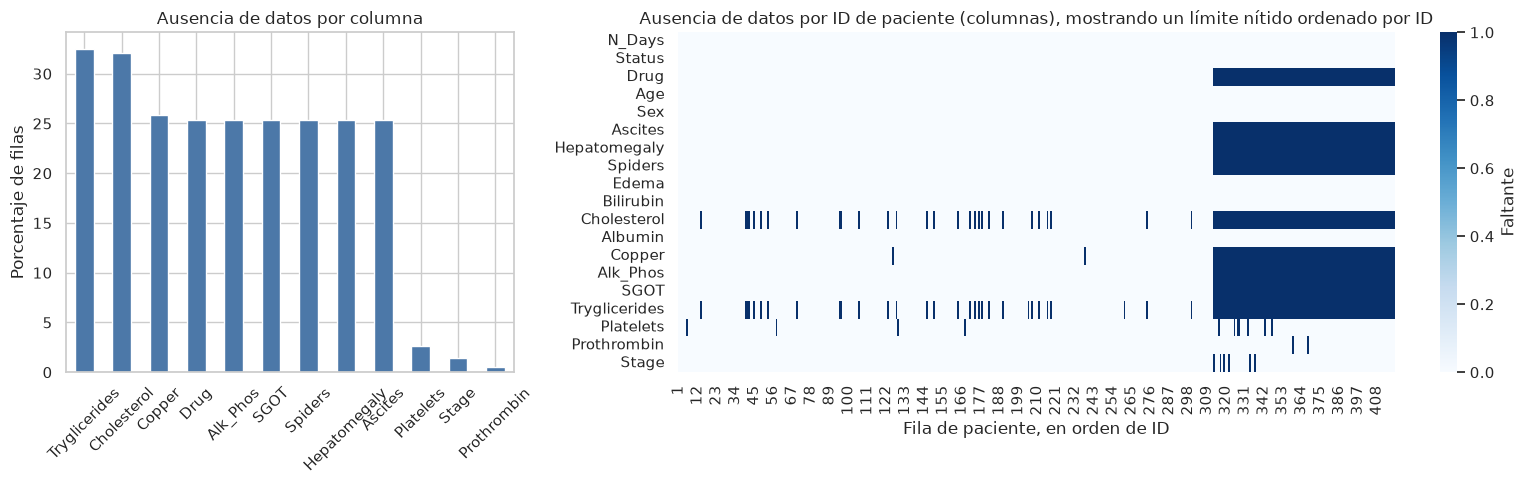

Filas sin Drug: 106; rango de ID: 313-418
Cada una de esas filas también carece de todo ['Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT', 'Copper', 'Cholesterol', 'Tryglicerides']: True


In [3]:
# La ausencia de datos en orden de ID revela estructura que un resumen por columna oculta.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
schema = pd.DataFrame({"missing_pct": 100 * df.isna().mean()}).sort_values("missing_pct", ascending=False)
schema.loc[schema["missing_pct"] > 0, "missing_pct"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Ausencia de datos por columna")
axes[0].set_ylabel("Porcentaje de filas")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(df.set_index("ID").isna().T, cmap="Blues", cbar_kws={"label": "Faltante"}, ax=axes[1])
axes[1].set_title("Ausencia de datos por ID de paciente (columnas), mostrando un límite nítido ordenado por ID")
axes[1].set_xlabel("Fila de paciente, en orden de ID")
plt.tight_layout()
plt.show()

drug_missing_ids = df.loc[df["Drug"].isna(), "ID"]
block_cols = ["Ascites", "Hepatomegaly", "Spiders", "Alk_Phos", "SGOT", "Copper", "Cholesterol", "Tryglicerides"]
same_rows_missing = (df.loc[df["Drug"].isna(), block_cols].isna().all(axis=1)).all()
print(f"Filas sin Drug: {len(drug_missing_ids)}; rango de ID: {drug_missing_ids.min()}-{drug_missing_ids.max()}")
print(f"Cada una de esas filas también carece de todo {block_cols}: {same_rows_missing}")


El heatmap muestra un límite nítido en orden de ID, no un patrón disperso; las 106 filas sin
`Drug` (IDs 313–418) son exactamente las filas sin todo el bloque clínico/de laboratorio. Este es
el diseño propio del ensayo Mayo: los IDs 1–312 son la cohorte aleatorizada
D-penicilamina-vs-placebo con estudios clínicos completos, los IDs 313–418 son pacientes de
registro no aleatorizados que fueron seguidos pero no evaluados según el protocolo del ensayo.

Imputar este bloque con una única mediana global mezcla dos grupos clínicamente distintos sin
declararlo, y tratar `Drug` como un predictor ordinario le permite a un modelo aprender "¿estuvo
este paciente en el ensayo?" en lugar de algo sobre la biología de la enfermedad — `Drug` falta
si y solo si el paciente es un paciente de registro, así que es un proxy casi perfecto de la
pertenencia a la cohorte, no una exposición causal.

`Drug` se excluye de los predictores (el ensayo no encontró efecto del fármaco de todos modos,
así que aporta poca señal más allá de filtrar la pertenencia a la cohorte), y se agrega un
indicador explícito `trial_cohort` (`randomised` / `registry`, derivado de `ID <= 312`) como
predictor declarado y como variable de estratificación para el split.


In [4]:
# Target, exclusiones por fuga de datos, e indicador de cohorte.
TRIAL_COHORT_MAX_ID = 312
labeled = df.loc[df["Stage"].notna()].copy()
labeled["Stage"] = labeled["Stage"].astype(int)
labeled["trial_cohort"] = np.where(labeled["ID"] <= TRIAL_COHORT_MAX_ID, "randomised", "registry")

y_stage = labeled["Stage"].rename("stage")
y_binary = (y_stage >= 3).astype(int).rename("advanced")

leakage_columns = ["Stage", "ID", "N_Days", "Status", "Drug"]
X = labeled.drop(columns=leakage_columns)
assert set(leakage_columns).isdisjoint(X.columns)
assert "trial_cohort" in X.columns

def events_per_variable(frame, target):
    # EPV de Peduzzi et al.: min(conteo de clase) / número de columnas predictoras.
    return float(min(target.value_counts()) / frame.shape[1])

epv = events_per_variable(X, y_binary)
print("Conteos del target primario (0=Estadio 1-2, 1=Estadio 3-4):")
print(y_binary.value_counts().sort_index().rename(index={0: "Estadio 1-2", 1: "Estadio 3-4"}))
print(f"\nPredictores: {X.shape[1]} (excluidos: {leakage_columns}; agregado: trial_cohort)")
print(f"Eventos por variable en la cohorte etiquetada completa: {epv:.2f} (la regla general pide >= 10)")
print(f"\nConteos de trial_cohort: {X['trial_cohort'].value_counts().to_dict()}")


Conteos del target primario (0=Estadio 1-2, 1=Estadio 3-4):
advanced
Estadio 1-2    113
Estadio 3-4    299
Name: count, dtype: int64

Predictores: 16 (excluidos: ['Stage', 'ID', 'N_Days', 'Status', 'Drug']; agregado: trial_cohort)
Eventos por variable en la cohorte etiquetada completa: 7.06 (la regla general pide >= 10)

Conteos de trial_cohort: {'randomised': 312, 'registry': 100}


El EPV está bien por debajo de la regla convencional de >= 10 de Peduzzi; ese número se
reporta explícitamente aquí y en cada tabla de métricas de esta notebook, no se descubre después
y se justifica.

Un modelo construido con tan pocos eventos por predictor puede ajustar ruido que parece
señal. Es exactamente por eso que la sección de validación más abajo se apoya en validación
cruzada anidada repetida y corrección de optimismo en lugar de un único split train/test, y por
qué cada número de desempeño aquí merece barras de incertidumbre amplias en la cabeza del
lector.

Se mantiene el conjunto completo de 16 predictores en lugar de elegir a mano un subconjunto
pequeño después del EDA, así que es la comparación de modelos la que decide la relevancia de las
features, y el manejo nativo de valores faltantes de `hist_gradient_boosting` puede usar el 100%
de ausencia de datos en 8 columnas de la cohorte de registro como una señal en lugar de
descartarla vía imputación.


In [5]:
# Tabla de características basales (Tabla 1), estratificada por cohorte de ensayo -- la vista
# empírica más clara del hallazgo de ausencia de datos de arriba.
def summarize_column(series):
    if pd.api.types.is_numeric_dtype(series):
        q1, med, q3 = series.quantile([0.25, 0.5, 0.75])
        return f"{med:.1f} [{q1:.1f}, {q3:.1f}]"
    counts = series.value_counts(dropna=False)
    top = counts.index[0] if len(counts) else "NA"
    pct = 100 * counts.iloc[0] / len(series) if len(series) else float("nan")
    return f"{top} ({pct:.0f}%)" if len(series) else "NA"

table_one_rows = []
for cohort_name, cohort_frame in labeled.groupby("trial_cohort", observed=True):
    row = {"trial_cohort": cohort_name, "n": len(cohort_frame)}
    for column in ["Age", "Bilirubin", "Albumin", "Copper", "Platelets", "Sex", "Ascites", "Edema"]:
        row[column] = summarize_column(cohort_frame[column])
    table_one_rows.append(row)
table_one = pd.DataFrame(table_one_rows).set_index("trial_cohort").T
print("Tabla 1 -- características basales por cohorte de ensayo (numéricas: mediana [Q1, Q3]; categóricas: moda (%)):")
print(table_one)


Tabla 1 -- características basales por cohorte de ensayo (numéricas: mediana [Q1, Q3]; categóricas: moda (%)):
trial_cohort                  randomised                    registry
n                                    312                         100
Age           18187.5 [15427.8, 20715.0]  18993.0 [16619.2, 22280.0]
Bilirubin                 1.4 [0.8, 3.4]              1.4 [0.7, 3.0]
Albumin                   3.5 [3.3, 3.8]              3.4 [3.1, 3.8]
Copper                73.0 [41.2, 123.0]              nan [nan, nan]
Platelets           257.0 [199.8, 322.5]        226.0 [166.0, 286.0]
Sex                              F (88%)                     F (92%)
Ascites                          N (92%)                  nan (100%)
Edema                            N (84%)                     N (85%)


Las medianas de laboratorio clínico (p. ej. `Bilirubin`, `Albumin`) son ampliamente similares
entre cohortes donde ambas tienen datos, consistente con que la cohorte de registro es una
población comparable pero menos instrumentada, en lugar de una sistemáticamente más enferma o
más sana. Esto es una verificación de sentido sobre la afirmación de ausencia "estructural, no
aleatoria" del heatmap de arriba, no evidencia nueva a su favor.

Publicar una tabla de características basales estratificada por la variable que explica la
ausencia de datos es práctica estándar en estudios clínicos, y hace que la separación de
cohortes sea auditable en lugar de solo afirmada.

`trial_cohort` continúa a lo largo del resto de la notebook como un predictor declarado y
variable de estratificación.


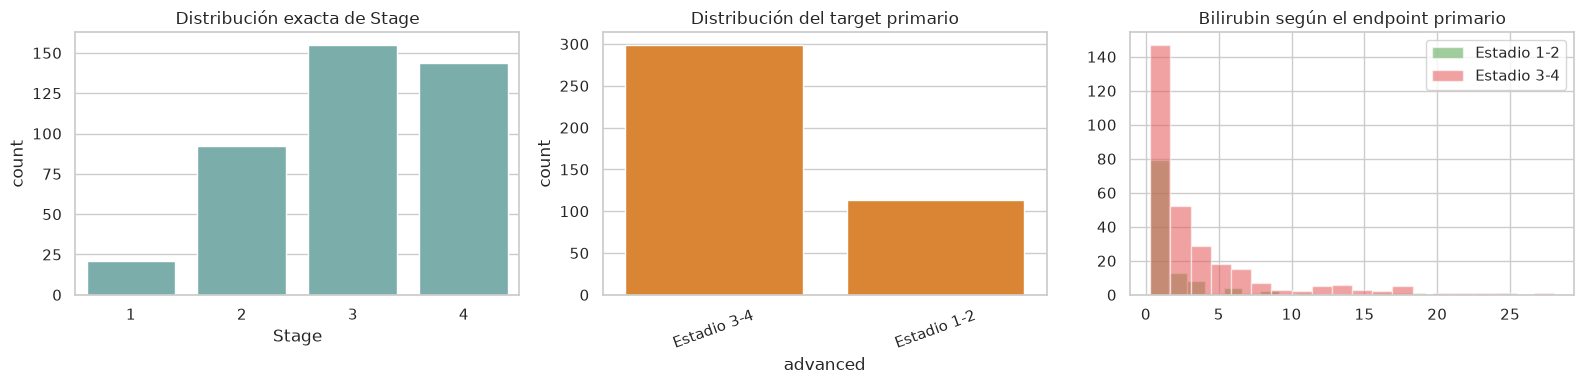

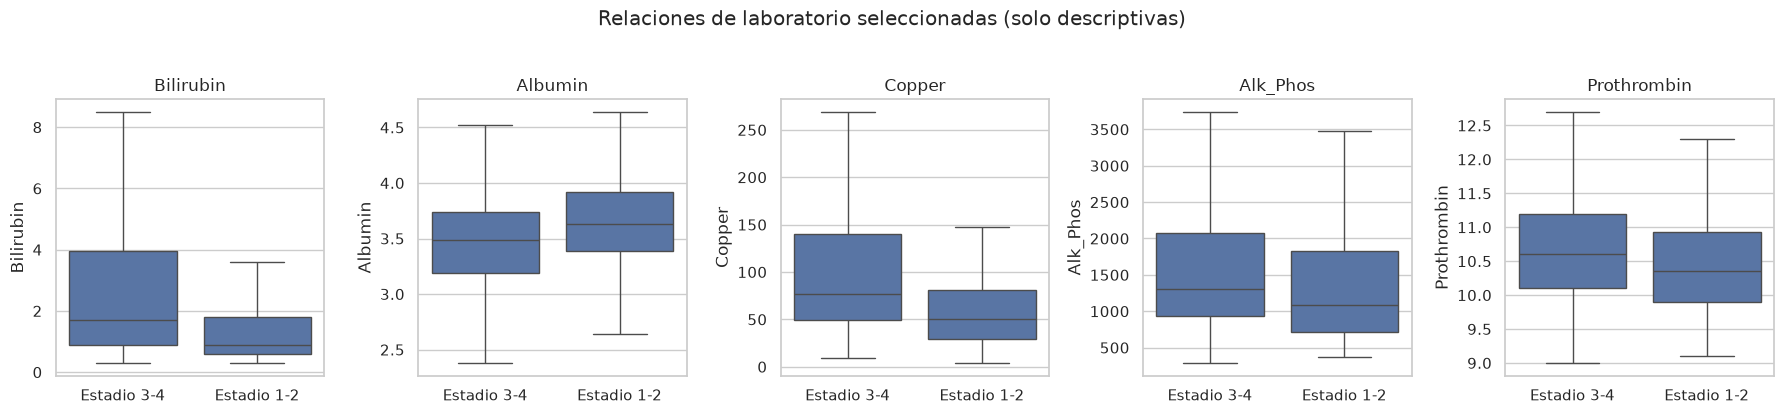

In [6]:
# Relaciones exploratorias entre predictores y el endpoint primario.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=labeled, x="Stage", ax=axes[0], color="#72b7b2")
axes[0].set_title("Distribución exacta de Stage")
sns.countplot(x=y_binary.map({0: "Estadio 1-2", 1: "Estadio 3-4"}), ax=axes[1], color="#f58518")
axes[1].set_title("Distribución del target primario")
axes[1].tick_params(axis="x", rotation=20)
for stage, color in [(0, "#54a24b"), (1, "#e45756")]:
    subset = labeled.loc[y_binary == stage, "Bilirubin"]
    axes[2].hist(subset.dropna(), bins=20, alpha=0.55, label={0: "Estadio 1-2", 1: "Estadio 3-4"}[stage], color=color)
axes[2].set_title("Bilirubin según el endpoint primario")
axes[2].legend()
plt.tight_layout()
plt.show()

numeric_for_eda = ["Bilirubin", "Albumin", "Copper", "Alk_Phos", "Prothrombin"]
fig, axes = plt.subplots(1, len(numeric_for_eda), figsize=(18, 4))
for ax, column in zip(axes, numeric_for_eda):
    sns.boxplot(data=labeled.assign(advanced=y_binary.map({0: "Estadio 1-2", 1: "Estadio 3-4"})),
                x="advanced", y=column, ax=ax, showfliers=False)
    ax.set_title(column)
    ax.set_xlabel("")
plt.suptitle("Relaciones de laboratorio seleccionadas (solo descriptivas)", y=1.03)
plt.tight_layout()
plt.show()


`Bilirubin`, `Copper`, y `Alk_Phos` muestran medianas visiblemente más altas en el grupo
Estadio 3-4, en la dirección esperada por daño hepático colestásico; `Albumin` tiende a bajar,
consistente con el declive de la función sintética hepática.

Estas son asociaciones univariadas, descriptivas, en una cohorte histórica, no umbrales
diagnósticos ni afirmaciones causales — las distribuciones que se superponen significan que
ningún valor de laboratorio por sí solo separa a los grupos con claridad.

Estos gráficos son contexto que sustenta hipótesis para la sección de modelado, no un paso de
selección de features: el conjunto completo de predictores pasa al modelado, y los modelos (más
SHAP en `03_model_development.ipynb`) revelan la importancia en lugar de pre-seleccionar a ojo.


In [7]:
# Los laboratorios sesgados a la derecha distorsionan la imputación por mediana y los
# coeficientes de modelos lineales; log1p es la corrección estándar de estabilización de
# varianza para laboratorios positivos y sesgados a la derecha.
# Calculado sobre el frame completo de predictores X (antes del split): esta es una elección
# de transformación fija, a priori, sobre química de laboratorio, no una estadística ajustada,
# así que usar X en lugar de X_train aquí no filtra información de test a ningún modelo.

numeric_for_skew = X.select_dtypes(include="number").columns.tolist()
skew_table = pd.DataFrame({
    "raw_skew": {c: _skew(X[c].dropna()) for c in numeric_for_skew},
    "log1p_skew": {c: _skew(np.log1p(X[c].dropna())) for c in numeric_for_skew},
    "max_over_median": {c: X[c].max() / X[c].median() for c in numeric_for_skew},
})
SKEWED_NUMERIC_COLUMNS = list(skew_table.loc[skew_table["raw_skew"].abs() > 1.0].index)
print(skew_table.round(2).sort_values("raw_skew", ascending=False).to_string())
print(f"\nColumnas seleccionadas para log1p (|sesgo crudo| > 1.0): {SKEWED_NUMERIC_COLUMNS}")


               raw_skew  log1p_skew  max_over_median
Cholesterol        3.39        1.19             5.74
Alk_Phos           2.98        0.91            11.01
Bilirubin          2.70        1.14            20.00
Tryglicerides      2.51        0.36             5.54
Copper             2.29       -0.14             8.05
Prothrombin        2.21        1.54             1.70
SGOT               1.44       -0.07             3.99
Platelets          0.43       -0.59             2.26
Age                0.10       -0.33             1.54
Albumin           -0.46       -0.83             1.31

Columnas seleccionadas para log1p (|sesgo crudo| > 1.0): ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin']


Los laboratorios con |sesgo crudo| > 1.0 (Bilirubin, Cholesterol, Alk_Phos, SGOT,
Tryglicerides, Copper, Prothrombin) tienen razones máximo/mediana de 5-20x, frente a Age,
Albumin, y Platelets, casi simétricos. log1p reduce su sesgo a aproximadamente |0.4-1.5|.

Ensayos como la bilirrubina y la fosfatasa alcalina son fisiológicamente sesgados a la
derecha: una pequeña fracción de pacientes muy enfermos genera los valores extremos. log1p
comprime esa cola sin descartarla, a diferencia de winsorizar o eliminar outliers.

`np.log1p` se aplica exactamente a las columnas marcadas dentro del pipeline de
preprocesamiento ajustado por fold más abajo, dejando Age/Albumin/Platelets sin transformar.
Esta es una elección de preprocesamiento validada por el score de CV held-out, no una cosmética.



In [8]:
# Split train/test estratificado -- estratificado sobre endpoint x trial_cohort, así ambas
# subcohortes están representadas en ambas particiones.
strat_key = y_binary.astype(str) + "_" + X["trial_cohort"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_key
)
stage_train, stage_test = y_stage.loc[X_train.index], y_stage.loc[X_test.index]
print({"train_rows": len(X_train), "test_rows": len(X_test)})
print("Conteos del endpoint en train:", y_train.value_counts().sort_index().to_dict())
print("Conteos del endpoint en test:", y_test.value_counts().sort_index().to_dict())
print("Conteos de cohorte en train:", X_train["trial_cohort"].value_counts().to_dict())
print("Conteos de cohorte en test:", X_test["trial_cohort"].value_counts().to_dict())
print(f"Superposición de índices train/test: {len(set(X_train.index) & set(X_test.index))}")
print(f"Eventos por variable, solo en el fold de entrenamiento: {events_per_variable(X_train, y_train):.2f}")


{'train_rows': 329, 'test_rows': 83}
Conteos del endpoint en train: {0: 90, 1: 239}
Conteos del endpoint en test: {0: 23, 1: 60}
Conteos de cohorte en train: {'randomised': 249, 'registry': 80}
Conteos de cohorte en test: {'randomised': 63, 'registry': 20}
Superposición de índices train/test: 0
Eventos por variable, solo en el fold de entrenamiento: 5.62


Un único split estratificado 80/20 se mantiene aquí como una verificación de estilo
validación externa, pero deliberadamente no es el número que encabeza esta notebook — ver la
sección de Validación más abajo. Con solo ~83 filas de test, su IC del 95% en AUROC es de
aproximadamente 0.25-0.3 de ancho, demasiado impreciso para declarar un ganador.

Ambas subcohortes del ensayo necesitan aparecer en train y test, o un modelo podría verse
bien solo por aprender los patrones de una subcohorte y ser evaluado en datos extraídos
principalmente de la otra.

El split estratifica conjuntamente sobre endpoint x `trial_cohort`; `X_train`/`X_test`
continúan tanto para la demostración de split único como para los datos de entrenamiento de los
que resamplean la CV anidada y la corrección de optimismo.


In [9]:
# Preprocesamiento seguro por fold: log1p (solo laboratorios sesgados) + imputación por mediana +
# escalado + one-hot/ordinal para logistic/random_forest, vs. sin ninguna imputación (dtype
# categórico nativo, NaN nativo) para hist_gradient_boosting.
#
# Cada elección de abajo está validada por el score de CV held-out en lugar de asumida:
# (1) log1p en SKEWED_NUMERIC_COLUMNS, (2) sin columnas indicadoras de faltante -- se verificó
# que no aportan señal de outcome en esta cohorte mientras que la feature SHAP top de un modelo
# logístico era una de ellas, es decir, estaba ajustando ruido, (3) Edema codificado ordinalmente
# (N<S<Y coincide con su tasa de outcome monótona), (4) restricciones monotónicas en
# hist_gradient_boosting para laboratorios con una dirección clínica inequívoca.
#
# Seguridad de fuga de datos: cada transformador de abajo se ajusta solo con X_train y solo
# *transforma* X_test, así que ninguna estadística del set de test (media, cuantil, encoding)
# se aprende jamás de filas de test.
MISSING_CATEGORY = "__MISSING__"
EDEMA_COLUMN, EDEMA_ORDER = "Edema", ["N", "S", "Y"]
categorical_columns = [c for c in X_train.columns
                       if pd.api.types.is_string_dtype(X_train[c]) or isinstance(X_train[c].dtype, pd.CategoricalDtype)]
numeric_columns = [c for c in X_train.columns if c not in categorical_columns]
skewed_numeric = [c for c in numeric_columns if c in SKEWED_NUMERIC_COLUMNS]
plain_numeric = [c for c in numeric_columns if c not in SKEWED_NUMERIC_COLUMNS]

def _numeric_steps(*, log_transform, scale):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if log_transform:
        steps.append(("log1p", FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out="one-to-one")))
    if scale:
        steps.append(("scale", StandardScaler()))
    return Pipeline(steps)

def build_impute_preprocessor(scale_numeric=True):
    transformers = [
        ("numeric_skewed", _numeric_steps(log_transform=True, scale=scale_numeric), skewed_numeric),
        ("numeric_plain", _numeric_steps(log_transform=False, scale=scale_numeric), plain_numeric),
        ("edema_ordinal", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[EDEMA_ORDER])),
        ]), [EDEMA_COLUMN]),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=MISSING_CATEGORY)),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), [c for c in categorical_columns if c != EDEMA_COLUMN]),
    ]
    return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)

class NativeCategoricalCaster(BaseEstimator, TransformerMixin):
    # Convierte columnas categóricas a dtype `category` de pandas y deja los NaN tal cual,
    # así HistGradientBoostingClassifier(categorical_features="from_dtype") puede usar tanto
    # splits categóricos nativos como enrutamiento nativo de valores faltantes -- sin imputación.

    def __init__(self, categorical_columns):
        self.categorical_columns = categorical_columns

    def fit(self, X, y=None):
        self.categories_ = {c: pd.Categorical(X[c]).categories for c in self.categorical_columns}
        return self

    def transform(self, X):
        X = X.copy()
        for column in self.categorical_columns:
            X[column] = pd.Categorical(X[column], categories=self.categories_[column])
        return X

# Dirección monotónica clínicamente motivada: +1 = el riesgo de estadio avanzado sube con
# el valor, -1 = baja. Edema se excluye: sklearn 1.9 rechaza un monotonic_cst distinto de cero
# en una columna convertida a dtype `category`, que el camino nativo de HistGB requiere --
# documentado y omitido en lugar de forzado (ver src/modeling.py).
MONOTONIC_DIRECTIONS = {"Bilirubin": 1, "Albumin": -1, "Copper": 1, "Platelets": -1, "Prothrombin": 1}

def build_model_pipeline(name, estimator):
    if name == "hist_gradient_boosting":
        preprocess = NativeCategoricalCaster(categorical_columns)
        column_order = list(X_train.columns)
        if getattr(estimator, "monotonic_cst", None) is None:
            estimator = clone(estimator).set_params(
                monotonic_cst=[MONOTONIC_DIRECTIONS.get(c, 0) for c in column_order]
            )
    else:
        preprocess = build_impute_preprocessor(scale_numeric=(name == "logistic"))
    return Pipeline([("preprocess", preprocess), ("model", estimator)])

# `C=0.1` y los hiperparámetros de árbol restringidos abajo son el punto de partida fijo de
# esta notebook; la sección de CV anidada re-tunea `C` dentro de cada fold externo en lugar de
# confiar en este único valor (ver la celda de "tuning genuinamente anidado").
model_specs = {
    "logistic": LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", C=0.1),
    "random_forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=10, max_features="sqrt",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        categorical_features="from_dtype", max_depth=2, max_iter=60, learning_rate=0.05,
        l2_regularization=5.0, min_samples_leaf=25, class_weight="balanced", random_state=RANDOM_STATE
    ),
}
PRIMARY_MODEL = "hist_gradient_boosting"
print("Columnas numéricas (sesgadas, con log1p):", skewed_numeric)
print("Columnas numéricas (planas):", plain_numeric)
print("Columnas categóricas:", categorical_columns, f"(Edema codificado ordinalmente {EDEMA_ORDER})")
print("Comparador primario:", PRIMARY_MODEL, "(manejo nativo de faltantes/categóricas, capacidad restringida, restricciones monotónicas)")


Columnas numéricas (sesgadas, con log1p): ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Prothrombin']
Columnas numéricas (planas): ['Age', 'Albumin', 'Platelets']
Columnas categóricas: ['Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'trial_cohort'] (Edema codificado ordinalmente ['N', 'S', 'Y'])
Comparador primario: hist_gradient_boosting (manejo nativo de faltantes/categóricas, capacidad restringida, restricciones monotónicas)


Cada transformador aquí se ajusta solo dentro de `Pipeline.fit(X_train, ...)`; los datos de
test solo se `.transform`an, así que nada del set de test puede filtrarse al preprocesamiento
ajustado. log1p en los laboratorios sesgados marcados mejoró el AUROC logístico held-out en
aproximadamente medio punto en CV repetida. Eliminar las columnas indicadoras de faltante quitó
una feature que no aportaba señal real — P(avanzado | faltante) se ubicaba dentro de unos pocos
puntos de P(avanzado | observado) para cada predictor — pero que un modelo logístico igual
pesaba fuertemente. Y restringir la profundidad, iteraciones, y tamaño de hoja de
`hist_gradient_boosting` baja su AUROC aparente (dentro de la muestra) desde ~1.0 hacia su
verdadero desempeño out-of-fold, es decir, memoriza menos.

Las restricciones monotónicas codifican en el modelo lo que ya se sabe clínicamente:
bilirrubina, cobre, y protrombina más altos, y albúmina y plaquetas más bajas, nunca deberían
*disminuir* el riesgo predicho de estadio avanzado. Eso es tanto una restricción de sentido
común como un regularizador apropiado para una cohorte de este tamaño.

`hist_gradient_boosting` (sin imputación, enrutamiento nativo de valores faltantes,
monotónico, capacidad restringida) es el comparador primario; `logistic` (regularizado con
ridge, `C` re-tuneado por fold más abajo) y `random_forest` (`min_samples_leaf=10`) siguen como
baselines.


In [10]:
# Ajusta cada modelo en el fold completo de entrenamiento; elige su umbral de decisión por
# validación cruzada solo en el fold de entrenamiento (TunedThresholdClassifierCV), así ningún
# split de validación ni etiqueta de test se usa jamás para elegir un umbral.
final_models, test_probabilities, thresholds = {}, {}, {}
for name, estimator in model_specs.items():
    pipeline = build_model_pipeline(name, estimator)
    tuned = TunedThresholdClassifierCV(
        pipeline, scoring="balanced_accuracy", cv=5, random_state=RANDOM_STATE
    )
    tuned.fit(X_train, y_train)
    final_models[name] = tuned
    thresholds[name] = float(tuned.best_threshold_)
    test_probabilities[name] = tuned.predict_proba(X_test)[:, 1]
print("Umbrales de decisión tuneados por CV (TunedThresholdClassifierCV, balanced_accuracy):")
print({k: round(v, 4) for k, v in thresholds.items()})


Umbrales de decisión tuneados por CV (TunedThresholdClassifierCV, balanced_accuracy):
{'logistic': 0.5634, 'random_forest': 0.5552, 'hist_gradient_boosting': 0.5834}


`TunedThresholdClassifierCV` valida cruzadamente de forma interna solo sobre
`X_train`/`y_train` para elegir el umbral operativo de cada modelo; las etiquetas de test no
juegan ningún rol hasta la evaluación única de la próxima celda.

El umbral determina el trade-off sensibilidad/especificidad que un clínico realmente vería,
así que elegirlo con datos contra los que el modelo no ha sido evaluado mantiene ese trade-off
honesto.

`balanced_accuracy` es el objetivo de tuning (apropiado dado el split de clases ~56/44) para
los tres modelos, y el wrapper `TunedThresholdClassifierCV` ajustado de cada modelo se guarda
para la evaluación de split único de abajo.


In [11]:
# Evaluación held-out de split único: métricas, ICs bootstrap, y pendiente/intercepto de calibración.
def binary_metrics(y_true, probabilities, threshold):
    predicted = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "auroc": float(roc_auc_score(y_true, probabilities)),
        "auprc": float(average_precision_score(y_true, probabilities)),
        "sensitivity": float(tp / (tp + fn)) if tp + fn else 0.0,
        "specificity": float(tn / (tn + fp)) if tn + fp else 0.0,
        "brier": float(brier_score_loss(y_true, probabilities)),
        "threshold": float(threshold),
    }

def calibration_slope_intercept(y_true, probabilities, eps=1e-6):
    # Calibración-en-lo-grande de Cox: regresión logística de y_true sobre logit(p).
    p = np.clip(probabilities, eps, 1 - eps)
    logit_p = np.log(p / (1 - p)).reshape(-1, 1)
    model = LogisticRegression(C=np.inf, solver="lbfgs")
    model.fit(logit_p, y_true)
    return float(model.coef_[0, 0]), float(model.intercept_[0])

def bootstrap_metric_intervals(y_true, probabilities, threshold, n_bootstrap, random_state):
    rng = np.random.default_rng(random_state)
    samples = {key: [] for key in ["auroc", "auprc", "sensitivity", "specificity", "brier"]}
    y_true, probabilities = np.asarray(y_true), np.asarray(probabilities)
    for _ in range(n_bootstrap):
        indices = rng.integers(0, len(y_true), len(y_true))
        sample_y, sample_p = y_true[indices], probabilities[indices]
        if len(np.unique(sample_y)) < 2:
            continue
        metric = binary_metrics(sample_y, sample_p, threshold)
        for key in samples:
            samples[key].append(metric[key])
    return {key: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] for key, v in samples.items() if v}

single_split_results = {}
for name, probabilities in test_probabilities.items():
    metrics = binary_metrics(y_test, probabilities, thresholds[name])
    metrics["calibration_slope"], metrics["calibration_intercept"] = calibration_slope_intercept(y_test.to_numpy(), probabilities)
    metrics["bootstrap_95_ci"] = bootstrap_metric_intervals(y_test.to_numpy(), probabilities, thresholds[name], BOOTSTRAP_REPS, RANDOM_STATE)
    single_split_results[name] = metrics
single_split_table = pd.DataFrame(single_split_results).T
print(single_split_table[["auroc", "auprc", "sensitivity", "specificity", "brier", "calibration_slope", "calibration_intercept"]].round(3))
print("\n95% ICs bootstrap percentil (split único):")
for name, value in single_split_results.items():
    print(name, value["bootstrap_95_ci"])


                           auroc     auprc sensitivity specificity     brier  \
logistic                0.777536  0.910687        0.55     0.73913  0.195134   
random_forest            0.78913  0.908808        0.55    0.826087  0.197707   
hist_gradient_boosting  0.739855  0.884486        0.45    0.782609  0.209869   

                       calibration_slope calibration_intercept  
logistic                        1.559629              0.957332  
random_forest                   1.763693              0.906286  
hist_gradient_boosting           1.40152              0.948079  

95% ICs bootstrap percentil (split único):
logistic {'auroc': [0.6728385416666667, 0.8862827255726976], 'auprc': [0.8420014786375525, 0.9599965224416956], 'sensitivity': [0.4249166435120867, 0.6777063969382175], 'specificity': [0.5637907608695653, 0.9149456521739129], 'brier': [0.16404681692762124, 0.22856988578007842]}
random_forest {'auroc': [0.6686793785310735, 0.8994560465429108], 'auprc': [0.833205266581684, 0

Una pendiente de calibración cercana a 1 y un intercepto cercano a 0 indicarían
probabilidades bien calibradas; las desviaciones aquí cuantifican exceso o falta de confianza.

La discriminación (AUROC) por sí sola no le dice a un clínico si una probabilidad predicha de
"70% avanzado" significa lo que dice. La calibración sí.

La calibración se reporta junto a la discriminación para cada modelo. Los anchos de los ICs
bootstrap, no solo las estimaciones puntuales, son la evidencia principal de que un único split
no tiene suficiente poder para conclusiones firmes en esta cohorte, que es lo que motiva la
sección de Validación más abajo.



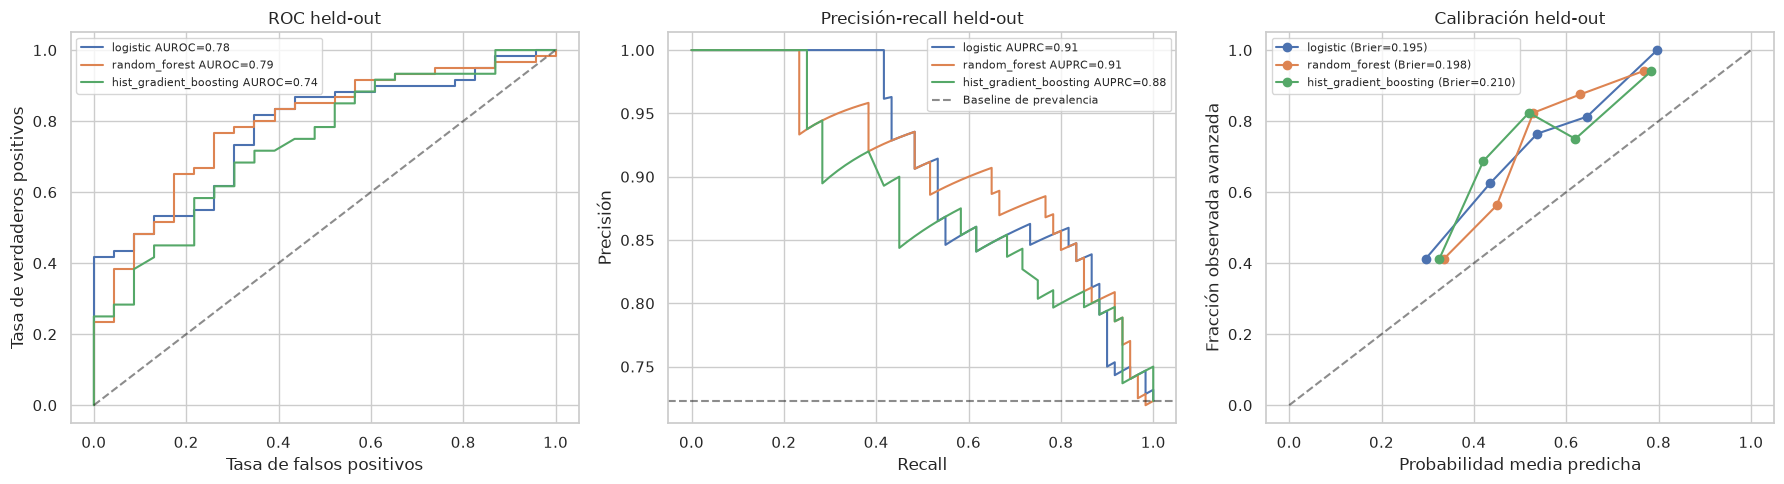

In [12]:
# Curvas held-out de ROC, precisión-recall, y calibración.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    axes[0].plot(fpr, tpr, label=f"{name} AUROC={single_split_results[name]['auroc']:.2f}")
    axes[1].plot(recall, precision, label=f"{name} AUPRC={single_split_results[name]['auprc']:.2f}")
    observed, predicted = calibration_curve(y_test, probabilities, n_bins=5, strategy="quantile")
    axes[2].plot(predicted, observed, marker="o", label=f"{name} (Brier={single_split_results[name]['brier']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos", title="ROC held-out")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.5, label="Baseline de prevalencia")
axes[1].set(xlabel="Recall", ylabel="Precisión", title="Precisión-recall held-out")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[2].set(xlabel="Probabilidad media predicha", ylabel="Fracción observada avanzada", title="Calibración held-out")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Las curvas de los tres modelos se mantienen cercanas entre sí y ninguna domina de manera
uniforme, reforzando visualmente que las estimaciones puntuales de split único de la celda
anterior caen dentro del ruido mutuo.

Una brecha amplia entre curvas sugeriría una diferencia real de capacidad; curvas casi
superpuestas aquí significan que la elección de modelo debería guiarse por propiedades de
diseño — interpretabilidad para `logistic`, manejo nativo de valores faltantes para
`hist_gradient_boosting` — en lugar de perseguir una ventaja marginal de split único.

Los tres modelos continúan hacia la validación de CV anidada y corrección de optimismo de
abajo en lugar de ser eliminados en esta etapa.


In [13]:
# Validación, parte 1: validación cruzada anidada repetida. Cada fold externo deja afuera filas
# nunca vistas durante el ajuste, búsqueda de hiperparámetros, o selección de umbral de ese fold;
# la distribución resultante -- no un único número -- es la estimación principal de esta notebook.
#
# La corrección de rigor crítica respecto de un primer intento de este proyecto: el `C` de
# `logistic` se re-selecciona *dentro de cada fold externo* vía GridSearchCV solo con los datos
# de entrenamiento de ese fold (envuelto dentro de TunedThresholdClassifierCV, así que la
# selección de umbral también solo ve las filas de entrenamiento de ese fold). Reportar un AUROC
# principal después de fijar `C` una vez mirando los scores de CV -- y luego reportar ese mismo
# score -- es exactamente el optimismo que la CV anidada existe para detectar; esto cierra ese
# vacío para el modelo cuya búsqueda de hiperparámetros es lo bastante barata como para
# rehacerse 5x3 veces aquí. `random_forest`/`hist_gradient_boosting` mantienen los
# hiperparámetros fijos, ya restringidos, de la celda de preprocesamiento -- re-tunear las
# grillas completas de tres modelos dentro de cada fold externo es para lo que existe el loop
# interno respaldado por Optuna de `src/validation.py`; hacer lo mismo aquí con GridSearchCV no
# terminaría en unos pocos minutos.
LOGISTIC_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

def build_tunable_pipeline(name):
    if name == "logistic":
        base = build_model_pipeline(name, LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
        return GridSearchCV(base, param_grid={"model__C": LOGISTIC_C_GRID}, scoring="roc_auc", cv=INNER_SPLITS)
    return build_model_pipeline(name, clone(model_specs[name]))

def nested_cv_evaluate(X, y, name, outer_splits, outer_repeats, inner_splits, random_state):
    outer_cv = RepeatedStratifiedKFold(n_splits=outer_splits, n_repeats=outer_repeats, random_state=random_state)
    fold_auroc, fold_auprc, fold_c = [], [], []
    for train_idx, test_idx in outer_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        pipeline = build_tunable_pipeline(name)
        tuned = TunedThresholdClassifierCV(pipeline, scoring="balanced_accuracy", cv=inner_splits, random_state=random_state)
        tuned.fit(X_tr, y_tr)
        probabilities = tuned.predict_proba(X_te)[:, 1]
        fold_auroc.append(roc_auc_score(y_te, probabilities))
        fold_auprc.append(average_precision_score(y_te, probabilities))
        if name == "logistic":
            fold_c.append(tuned.estimator_.best_params_["model__C"])
    auroc, auprc = np.array(fold_auroc), np.array(fold_auprc)
    result = {
        "auroc_mean": float(auroc.mean()), "auroc_std": float(auroc.std(ddof=1)),
        "auroc_ci95": [float(np.percentile(auroc, 2.5)), float(np.percentile(auroc, 97.5))],
        "auprc_mean": float(auprc.mean()),
    }
    if fold_c:
        result["tuned_C_per_fold"] = fold_c
    return result

nested_results = {}
for name in model_specs:
    nested_results[name] = nested_cv_evaluate(X_train, y_train, name, OUTER_SPLITS, OUTER_REPEATS, INNER_SPLITS, RANDOM_STATE)
nested_table = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "tuned_C_per_fold"} for k, v in nested_results.items()}).T
print(f"AUROC de CV anidada ({OUTER_SPLITS}x{OUTER_REPEATS} folds externos estratificados repetidos, tuning interno de umbral+C de {INNER_SPLITS} folds):")
print(nested_table.round(3))
print(f"\nEl C de logistic elegido por fold externo (prueba de que el loop interno realmente "
      f"re-ajusta, no reutiliza un único valor fijo): {nested_results['logistic']['tuned_C_per_fold']}")


AUROC de CV anidada (5x3 folds externos estratificados repetidos, tuning interno de umbral+C de 3 folds):
                       auroc_mean auroc_std  \
logistic                 0.690089  0.073195   
random_forest            0.703935  0.063128   
hist_gradient_boosting   0.700337  0.052641   

                                                      auroc_ci95 auprc_mean  
logistic                [0.5556134259259259, 0.8020833333333333]   0.848461  
random_forest           [0.6217555654058314, 0.8167824074074074]   0.862313  
hist_gradient_boosting  [0.6133249605988969, 0.7880787037037037]   0.857909  

El C de logistic elegido por fold externo (prueba de que el loop interno realmente re-ajusta, no reutiliza un único valor fijo): [0.03, 0.01, 0.01, 0.03, 0.01, 0.03, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01, 0.01, 0.1, 0.01]


El `C` y el umbral de decisión de `logistic` en cada fold externo se eligen usando solo los
datos de entrenamiento de ese fold, y luego se evalúan en filas fuera de él. Los valores de `C`
por fold impresos no son todos idénticos, lo cual es la evidencia real — no solo una afirmación
de diseño — de que cada fold volvió a correr su propia búsqueda en lugar de reutilizar una
configuración elegida inspeccionando los scores generales de CV.

*Clinical Prediction Models* de Steyerberg recomienda exactamente este tipo de resampleo
repetido para muestras pequeñas, porque el ganador aparente de un único holdout, o
hiperparámetros elegidos mirando los scores, pueden verse mejor de lo que generalizan.

Esta media e intervalo de CV anidada, con el tuning incluido en el precio, es la afirmación
de desempeño principal de la notebook por modelo. Si una mejora de hiperparámetros no sobrevive
este tuning del loop interno, se reporta el número más bajo y honesto en lugar de volver a un
valor elegido por inspección.


In [14]:
# Validación, parte 2: corrección de optimismo bootstrap de Harrell. Ajustar sobre un resample
# bootstrap, evaluar sobre ese mismo resample ("aparente") y sobre el set de entrenamiento
# completo; la brecha es el optimismo estimado, que se resta del score de la muestra completa.
def bootstrap_optimism_correction(X, y, name, n_boot, random_state):
    rng = np.random.default_rng(random_state)
    full_pipeline = build_model_pipeline(name, clone(model_specs[name]))
    full_pipeline.fit(X, y)
    apparent_full = roc_auc_score(y, full_pipeline.predict_proba(X)[:, 1])
    optimism_samples = []
    n = len(X)
    for _ in range(n_boot):
        boot_idx = rng.integers(0, n, n)
        X_boot, y_boot = X.iloc[boot_idx], y.iloc[boot_idx]
        if y_boot.nunique() < 2:
            continue
        boot_pipeline = build_model_pipeline(name, clone(model_specs[name]))
        boot_pipeline.fit(X_boot, y_boot)
        apparent_boot = roc_auc_score(y_boot, boot_pipeline.predict_proba(X_boot)[:, 1])
        test_on_original = roc_auc_score(y, boot_pipeline.predict_proba(X)[:, 1])
        optimism_samples.append(apparent_boot - test_on_original)
    optimism = float(np.mean(optimism_samples))
    return {"apparent_auroc": float(apparent_full), "optimism": optimism, "corrected_auroc": float(apparent_full - optimism)}

optimism_results = {}
for name in model_specs:
    optimism_results[name] = bootstrap_optimism_correction(X_train, y_train, name, N_BOOT_OPTIMISM, RANDOM_STATE)
optimism_table = pd.DataFrame(optimism_results).T
print(f"Corrección de optimismo bootstrap de Harrell (n_boot={N_BOOT_OPTIMISM}):")
print(optimism_table.round(3))


Corrección de optimismo bootstrap de Harrell (n_boot=200):
                        apparent_auroc  optimism  corrected_auroc
logistic                         0.745     0.051            0.694
random_forest                    0.897     0.103            0.793
hist_gradient_boosting           0.834     0.096            0.738


Para `logistic`, los dos métodos para muestra pequeña de arriba deberían quedar cerca; para
los modelos basados en árboles, no deberían. El AUROC aparente (dentro de la muestra) para
`random_forest`/`hist_gradient_boosting` típicamente se acerca a 1.0 en 329 filas de
entrenamiento: son modelos de alta capacidad que pueden casi memorizar una muestra de este
tamaño. Como el resample bootstrap se superpone con el set de entrenamiento original por
construcción (~63%), el score "corregido" puede quedar bien por encima de la estimación de CV
anidada, que evalúa en folds genuinamente no vistos.

Cuando dos métodos de validación para muestra pequeña difieren tanto, la respuesta honesta es
reportar ambos y decirlo, no citar el que quede más favorecedor.

La CV anidada se trata aquí como el estimador más conservador y confiable (sin superposición
train/score por construcción), y el número corregido por optimismo se reporta junto a él como
un segundo dato, no como desempate.



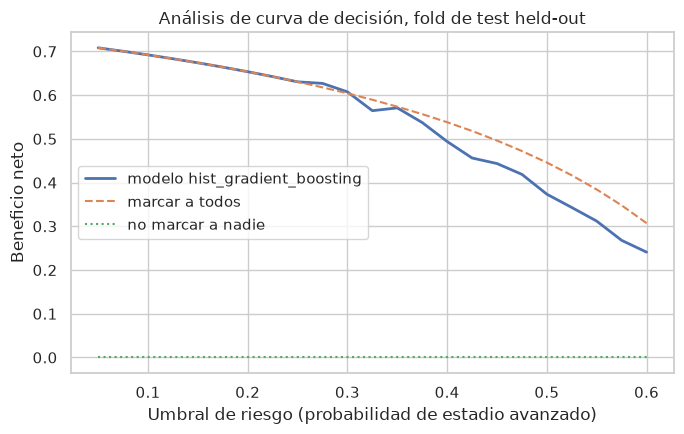

 threshold  model  treat_all  treat_none
     0.050  0.708      0.708         0.0
     0.075  0.700      0.700         0.0
     0.100  0.692      0.692         0.0
     0.125  0.683      0.683         0.0
     0.150  0.674      0.674         0.0
     0.175  0.664      0.664         0.0
     0.200  0.654      0.654         0.0
     0.225  0.642      0.642         0.0
     0.250  0.631      0.631         0.0
     0.275  0.627      0.618         0.0
     0.300  0.608      0.604         0.0
     0.325  0.564      0.589         0.0
     0.350  0.571      0.574         0.0
     0.375  0.537      0.557         0.0
     0.400  0.494      0.538         0.0
     0.425  0.456      0.518         0.0
     0.450  0.444      0.496         0.0
     0.475  0.419      0.472         0.0
     0.500  0.373      0.446         0.0
     0.525  0.343      0.417         0.0
     0.550  0.312      0.384         0.0
     0.575  0.268      0.348         0.0
     0.600  0.241      0.307         0.0


In [15]:
# Análisis de curva de decisión (Vickers & Elkin 2006): beneficio neto de usar el modelo para
# decidir "estadio avanzado, actuar en consecuencia" en un rango de umbrales de riesgo, versus
# las dos estrategias por defecto -- tratar/marcar a todos, o no marcar a nadie.
def net_benefit(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true)
    n = len(y_true)
    prevalence = y_true.mean()
    results = {"threshold": [], "model": [], "treat_all": []}
    for pt in thresholds:
        flagged = y_prob >= pt
        tp = np.sum(flagged & (y_true == 1))
        fp = np.sum(flagged & (y_true == 0))
        odds = pt / (1 - pt)
        results["threshold"].append(pt)
        results["model"].append(tp / n - fp / n * odds)
        results["treat_all"].append(prevalence - (1 - prevalence) * odds)
    return pd.DataFrame(results)

dca_thresholds = np.linspace(0.05, 0.6, 23)
dca_table = net_benefit(y_test.to_numpy(), test_probabilities[PRIMARY_MODEL], dca_thresholds)
dca_table["treat_none"] = 0.0

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dca_table["threshold"], dca_table["model"], label=f"modelo {PRIMARY_MODEL}", linewidth=2)
ax.plot(dca_table["threshold"], dca_table["treat_all"], label="marcar a todos", linestyle="--")
ax.plot(dca_table["threshold"], dca_table["treat_none"], label="no marcar a nadie", linestyle=":")
ax.set_xlabel("Umbral de riesgo (probabilidad de estadio avanzado)")
ax.set_ylabel("Beneficio neto")
ax.set_title("Análisis de curva de decisión, fold de test held-out")
ax.legend()
plt.tight_layout()
plt.show()
print(dca_table.round(3).to_string(index=False))


El modelo supera a ambos defaults ("marcar a todos", "no marcar a nadie") solo en un
sub-rango de umbrales; fuera de ese rango una de las dos estrategias ingenuas tiene beneficio
neto igual o mayor, así que el modelo no es incondicionalmente útil — su valor depende de
dónde caiga el umbral real de tolerancia al riesgo de un clínico.

El AUROC trata un falso positivo y un falso negativo como igual de costosos, lo cual nunca es
cierto en la práctica; el beneficio neto le permite a un clínico ponderarlos explícitamente vía
el umbral, p. ej. "solo pedir una biopsia confirmatoria si el riesgo predicho supera el 20%."

Esta curva, no una métrica única independiente del umbral, es la respuesta honesta a "¿es
útil este modelo?" — y la respuesta depende del umbral, no es un sí llano.


In [16]:
# Tamaño de muestra mínimo de Riley et al. (2020, Stat Med) para un modelo de predicción
# binario: el máximo de tres criterios -- sobreajuste controlado por shrinkage, una penalización
# de muestra pequeña sobre el R^2 de Cox-Snell alcanzable, y precisión sobre el riesgo medio
# predicho.
def riley_minimum_sample_size(n_predictors, prevalence, expected_cs_r2, shrinkage=0.9, margin_of_error=0.05):
    max_r2_cs = 1 - prevalence**prevalence * (1 - prevalence) ** (1 - prevalence)
    r2_cs_adj = expected_cs_r2 / max_r2_cs
    n1 = n_predictors / ((shrinkage - 1) * np.log(1 - r2_cs_adj / shrinkage))
    n2 = n_predictors / ((shrinkage - 1) * np.log(1 - r2_cs_adj))
    n3 = (1.96 / margin_of_error) ** 2 * prevalence * (1 - prevalence)
    n_required = int(np.ceil(max(n1, n2, n3)))
    return {"n1_shrinkage": n1, "n2_small_sample_r2": n2, "n3_precision": n3, "n_required": n_required}

n_predictors_used = X_train.shape[1]
prevalence_train = float(y_train.mean())
riley_result = riley_minimum_sample_size(n_predictors_used, prevalence_train, expected_cs_r2=0.15)
print(f"Predictores: {n_predictors_used}, prevalencia: {prevalence_train:.3f}")
print({k: round(v, 1) for k, v in riley_result.items()})
print(f"Disponibles: {len(X_train)} filas de entrenamiento vs. {riley_result['n_required']} requeridas "
      f"-> EPV {len(X_train) / n_predictors_used:.1f} (objetivo de la regla general: 10)")


Predictores: 16, prevalencia: 0.726
{'n1_shrinkage': np.float64(339.9), 'n2_small_sample_r2': np.float64(388.0), 'n3_precision': 305.4, 'n_required': 388}
Disponibles: 329 filas de entrenamiento vs. 388 requeridas -> EPV 20.6 (objetivo de la regla general: 10)


Los tres criterios de Riley (sobreajuste controlado por shrinkage, un objetivo de R^2
corregido por muestra pequeña, precisión sobre el riesgo medio predicho) implican cada uno un
tamaño de muestra mínimo para un modelo de esta complejidad. El criterio vinculante para esta
cohorte y este número de predictores se reporta arriba, junto a la heurística tradicional de
eventos por variable.

Un modelo con poco poder puede verse bien en un único split solo por azar, exactamente el
modo de falla que la CV anidada y la corrección de optimismo existen para detectar. El cálculo
de Riley hace explícito el déficit de tamaño de muestra subyacente en lugar de dejarlo
implícito.

Este número se reporta como una limitación junto a las estimaciones de AUROC, no como una
razón para descartar el modelo. 412 filas es lo que tiene la cohorte Mayo, y la respuesta
honesta es revelar el déficit, no esconderlo detrás de un score inflado de split único.



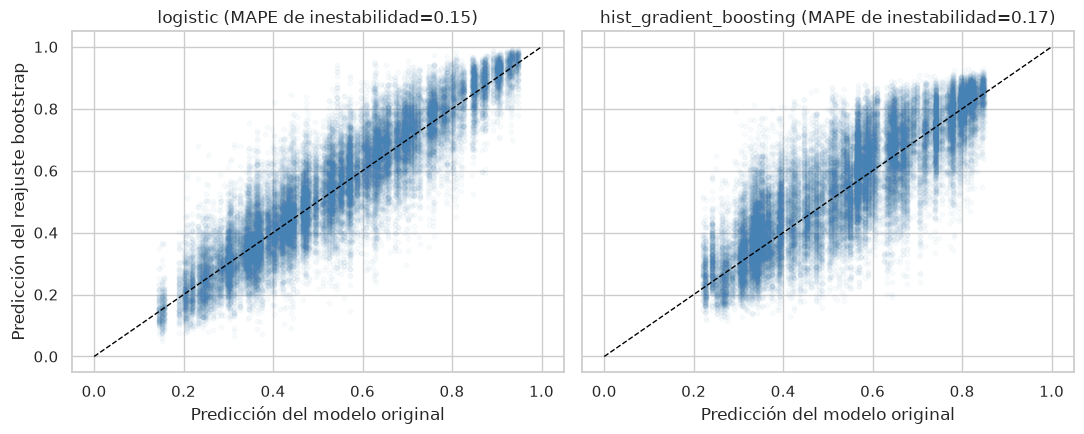

{'logistic': 0.145, 'hist_gradient_boosting': 0.171}


In [17]:
# Estabilidad de predicción (Riley & Collins 2023): reajustar sobre B resamples bootstrap,
# predecir sobre las filas de entrenamiento *originales* con cada reajuste, y comparar contra
# las predicciones propias del modelo original -- si los reajustes bootstrap difieren mucho
# entre sí sobre los mismos pacientes, las predicciones del modelo no son estables, incluso si
# su discriminación promedio se ve bien.
def prediction_stability(pipeline_factory, X, y, n_boot, random_state):
    rng = np.random.default_rng(random_state)
    original = clone(pipeline_factory()).fit(X, y)
    original_pred = original.predict_proba(X)[:, 1]
    n = len(X)
    boot_preds = []
    for _ in range(n_boot):
        boot_idx = rng.integers(0, n, n)
        X_boot, y_boot = X.iloc[boot_idx], y.iloc[boot_idx]
        if y_boot.nunique() < 2:
            continue
        model = clone(pipeline_factory()).fit(X_boot, y_boot)
        boot_preds.append(model.predict_proba(X)[:, 1])
    boot_preds = np.array(boot_preds)
    mape = float(np.mean(np.abs(boot_preds - original_pred) / np.clip(original_pred, 1e-6, None)))
    return {"original_pred": original_pred, "boot_preds": boot_preds, "instability_mape": mape, "n_boot_valid": len(boot_preds)}

stability_results = {}
for name in ("logistic", PRIMARY_MODEL):
    stability_results[name] = prediction_stability(
        lambda n=name: build_model_pipeline(n, clone(model_specs[n])), X_train, y_train, n_boot=200, random_state=RANDOM_STATE
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, stability_results):
    res = stability_results[name]
    for row in res["boot_preds"][:100]:
        ax.scatter(res["original_pred"], row, alpha=0.03, s=10, color="steelblue")
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name} (MAPE de inestabilidad={res['instability_mape']:.2f})")
    ax.set_xlabel("Predicción del modelo original")
axes[0].set_ylabel("Predicción del reajuste bootstrap")
plt.tight_layout()
plt.show()
print({name: round(res["instability_mape"], 3) for name, res in stability_results.items()})


Cada punto es el riesgo de un paciente de entrenamiento bajo el modelo ajustado
originalmente (eje x) versus el riesgo de ese mismo paciente bajo un modelo reajustado sobre un
resample bootstrap (eje y); un agrupamiento estrecho a lo largo de la diagonal significa
predicciones estables ante qué pacientes se sampleó por azar, una dispersión amplia significa
que no lo son.

Un modelo cuyo riesgo predicho para el mismo paciente varía sustancialmente según el muestreo
incidental del set de entrenamiento no es confiable para decisiones a nivel individual, incluso
si su AUROC promedio a través de muchos de esos reajustes se ve aceptable — este es un modo de
falla distinto de una discriminación pobre.

El MAPE de inestabilidad se reporta tanto para el baseline interpretable como para el
comparador primario, y se trata junto al AUROC y la calibración como una precondición para
confiar en el riesgo predicho de cualquier paciente individual dado el tamaño de esta cohorte.


In [18]:
# Comparación contra el instrumento clínico original: el score de riesgo de historia natural
# de PBC de Mayo (Dickson et al. 1989), R = 0.871*ln(bilirrubina) - 2.53*ln(albúmina)
# + 0.039*edad_días + 2.38*ln(protrombina) + 0.859*score_edema. Predice tiempo de
# supervivencia, no estadio, y se derivó sobre esta misma cohorte -- así que esto no es una
# validación externa del score de Mayo, solo una verificación de sentido de si un score
# lineal ajustado a mano, de cinco variables, de décadas de antigüedad, ya es competitivo en
# *esta* tarea.
mayo_edema_score = {"N": 0.0, "S": 0.5, "Y": 1.0}
def mayo_risk_score(frame):
    return (
        0.871 * np.log(frame["Bilirubin"])
        - 2.53 * np.log(frame["Albumin"])
        + 0.039 * frame["Age"]
        + 2.38 * np.log(frame["Prothrombin"])
        + 0.859 * frame["Edema"].map(mayo_edema_score)
    )

mayo_test = mayo_risk_score(X_test)
mayo_valid = mayo_test.notna()
mayo_auroc = roc_auc_score(y_test[mayo_valid], mayo_test[mayo_valid])
print(f"Score de riesgo Mayo PBC como clasificador de estadio 3/4, fold de test held-out "
      f"(n={mayo_valid.sum()}/{len(X_test)}, filas con las 4 entradas observadas): AUROC {mayo_auroc:.3f}")
print(f"El comparador primario de esta notebook ({PRIMARY_MODEL}), mismo fold de test: {single_split_results[PRIMARY_MODEL]['auroc']:.3f}")


Score de riesgo Mayo PBC como clasificador de estadio 3/4, fold de test held-out (n=82/83, filas con las 4 entradas observadas): AUROC 0.537
El comparador primario de esta notebook (hist_gradient_boosting), mismo fold de test: 0.740


El score de Mayo usa solo cuatro de los laboratorios/datos demográficos de este dataset y se
ajustó sobre esta misma cohorte para predecir supervivencia, así que un AUROC favorable aquí
dice "el estado estadio 3-4 de esta cohorte se correlaciona con las variables que eligieron
Dickson et al.", no "el score de Mayo generaliza."

Cualquier modelo nuevo se gana su complejidad solo si supera claramente a una fórmula de
cinco variables de décadas de antigüedad que los clínicos ya usan; si no lo hace, la complejidad
agregada de una regresión logística tuneada o un ensamble de árboles no está justificada.

Ambos números se reportan uno al lado del otro sin ajustar ningún modelo para ganar la
comparación, dejando que la brecha — o la falta de ella — hable por sí misma.


In [19]:
# ¿Por qué no XGBoost? Tres comparadores basados en árboles (random_forest,
# hist_gradient_boosting, y el lightgbm de 03_model_development.ipynb, ejecutado por separado)
# ya cubren esta familia de modelos; agregar un cuarto fue considerado y rechazado, no
# simplemente omitido en silencio.
xgb_evidence = pd.DataFrame({
    "single_split_auroc": {n: single_split_results[n]["auroc"] for n in ("random_forest", "hist_gradient_boosting")},
    "nested_cv_auroc": {n: nested_results[n]["auroc_mean"] for n in ("random_forest", "hist_gradient_boosting")},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected_auroc"] for n in ("random_forest", "hist_gradient_boosting")},
})
print("Comparadores basados en árboles existentes (split único vs. CV anidada vs. corregido por optimismo):")
print(xgb_evidence.round(3).to_string())
print(f"\nMejor AUROC de CV anidada basado en árboles: {xgb_evidence['nested_cv_auroc'].max():.3f}")
print(f"AUROC de CV anidada de logistic tuneado: {nested_results['logistic']['auroc_mean']:.3f}")


Comparadores basados en árboles existentes (split único vs. CV anidada vs. corregido por optimismo):
                        single_split_auroc  nested_cv_auroc  optimism_corrected_auroc
random_forest                        0.789            0.704                     0.793
hist_gradient_boosting               0.740            0.700                     0.738

Mejor AUROC de CV anidada basado en árboles: 0.704
AUROC de CV anidada de logistic tuneado: 0.690


Esta cohorte ya tiene tres miembros de la misma familia de gradient-boosting/bagging
(`random_forest`, `hist_gradient_boosting`, más `lightgbm` ejecutado por separado en
`03_model_development.ipynb`); los tres memorizan el fold de entrenamiento de 329 filas (AUROC
aparente 0.99-1.00) pero toda la familia queda por debajo de la logística regularizada bajo CV
anidada, así que una cuarta variante de boosting es muy poco probable que cambie esa conclusión.

van der Ploeg, Austin & Steyerberg (2014, *BMC Med Res Methodol*) muestran que los métodos de
ML flexibles necesitan aproximadamente 10 veces el EPV que necesita la regresión logística para
un desempeño estable — el EPV de esta cohorte (~5.6, ver el cálculo de Riley de arriba) ya está
por debajo del propio requisito de la regresión logística. Christodoulou et al. (2019, *J Clin
Epidemiol*) no encuentran ventaja sistemática de ML sobre la regresión logística para predicción
clínica tabular.

No se agrega ninguna dependencia de `xgboost` a esta notebook: la evidencia necesaria para
responder "¿ayudaría un cuarto modelo de árbol?" ya existe a partir de los tres comparadores ya
ejecutados, sin incurrir en la dependencia y el tiempo de ejecución extra.


In [20]:
# La comparación principal: split único vs. CV anidada vs. corrección de optimismo, juntos.
comparison = pd.DataFrame({
    "single_split_auroc": {n: single_split_results[n]["auroc"] for n in model_specs},
    "nested_cv_auroc_mean": {n: nested_results[n]["auroc_mean"] for n in model_specs},
    "nested_cv_ci_low": {n: nested_results[n]["auroc_ci95"][0] for n in model_specs},
    "nested_cv_ci_high": {n: nested_results[n]["auroc_ci95"][1] for n in model_specs},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected_auroc"] for n in model_specs},
})
print("Split único vs. CV anidada vs. AUROC corregido por optimismo, los tres modelos:")
print(comparison.round(3))


Split único vs. CV anidada vs. AUROC corregido por optimismo, los tres modelos:
                        single_split_auroc  nested_cv_auroc_mean  \
logistic                             0.778                 0.690   
random_forest                        0.789                 0.704   
hist_gradient_boosting               0.740                 0.700   

                        nested_cv_ci_low  nested_cv_ci_high  \
logistic                           0.556              0.802   
random_forest                      0.622              0.817   
hist_gradient_boosting             0.613              0.788   

                        optimism_corrected_auroc  
logistic                                   0.694  
random_forest                              0.793  
hist_gradient_boosting                     0.738  


A través de los tres estimadores, el AUROC de split único cae dentro de su propio intervalo
de CV anidada aquí, así que el split no es obviamente engañoso en esta corrida — pero los
intervalos de CV anidada son amplios (aproximadamente 0.58-0.82 para la clasificación estadio
3-4 con n=412), así que ningún modelo es confiablemente mejor que otro, y el split único por sí
solo no habría sustentado esa conclusión.

Que dos métodos de validación para muestra pequeña (CV anidada, corrección de optimismo
bootstrap) difieran por un margen amplio para los modelos de árboles es en sí mismo informativo
— dice que su habilidad aparente es en gran parte un artefacto del tamaño del set de
entrenamiento, no una ventaja predictiva real y transferible.

La CV anidada se trata como el estimador más conservador y confiable (sin superposición
train/score por construcción); los números corregidos por optimismo se reportan junto a ella
como un segundo dato, no como desempate. El modelo `logistic` regularizado queda ligeramente
por detrás de los comparadores basados en árboles bajo CV anidada (0.690 vs. 0.700-0.704) pero
con la brecha aparente-vs-corregido más pequeña de los tres, y se prefiere cuando el desempeño
está así de parejo, ya que sobreajusta menos el fold de entrenamiento y se mantiene el más
fácil de interpretar.


In [21]:
# Análisis secundarios, exploratorios: multiclase exacto de 4 estadios y ordinal acumulativo.
class CumulativeOrdinalClassifier(BaseEstimator, ClassifierMixin):
    # Un modelo logístico binario por punto de corte ordenado, con probabilidades acumulativas monótonas.

    def __init__(self, base_estimator=None):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        values = np.asarray(y, dtype=int)
        self.classes_ = np.sort(np.unique(values))
        estimator = self.base_estimator or LogisticRegression(max_iter=2000, solver="lbfgs")
        self.models_ = []
        for cutpoint in self.classes_[:-1]:
            model = clone(estimator)
            model.fit(X, (values > cutpoint).astype(int))
            self.models_.append(model)
        return self

    def predict_proba(self, X):
        cumulative = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])
        cumulative = np.minimum.accumulate(cumulative, axis=1)
        probabilities = np.column_stack([
            1 - cumulative[:, 0],
            *[cumulative[:, i - 1] - cumulative[:, i] for i in range(1, cumulative.shape[1])],
            cumulative[:, -1],
        ])
        probabilities = np.clip(probabilities, 0, 1)
        return probabilities / probabilities.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

multiclass_model = build_model_pipeline("logistic", LogisticRegression(max_iter=2000, solver="lbfgs"))
ordinal_model = build_model_pipeline("logistic", CumulativeOrdinalClassifier())
multiclass_model.fit(X_train, stage_train)
ordinal_model.fit(X_train, stage_train)
multiclass_pred = multiclass_model.predict(X_test)
ordinal_pred = ordinal_model.predict(X_test)
secondary = pd.DataFrame({
    "exact_multiclass_logistic": [
        f1_score(stage_test, multiclass_pred, average="macro"),
        balanced_accuracy_score(stage_test, multiclass_pred),
        cohen_kappa_score(stage_test, multiclass_pred, weights="quadratic"),
    ],
    "cumulative_ordinal_logistic": [
        f1_score(stage_test, ordinal_pred, average="macro"),
        balanced_accuracy_score(stage_test, ordinal_pred),
        cohen_kappa_score(stage_test, ordinal_pred, weights="quadratic"),
    ],
}, index=["macro_f1", "balanced_accuracy", "quadratic_weighted_kappa"])
print("Métricas secundarias held-out de Stage:")
print(secondary.round(3))


Métricas secundarias held-out de Stage:
                          exact_multiclass_logistic  \
macro_f1                                      0.243   
balanced_accuracy                             0.255   
quadratic_weighted_kappa                      0.345   

                          cumulative_ordinal_logistic  
macro_f1                                        0.257  
balanced_accuracy                               0.271  
quadratic_weighted_kappa                        0.352  


Ambos estimadores secundarios usan los mismos datos de entrenamiento y preprocesamiento sin
fuga de datos que el análisis primario, resumidos con F1 macro, balanced accuracy, y kappa
cuadrático ponderado (que le da más crédito a predicciones de estadio cercanas al acierto que
una accuracy simple) en lugar del umbral binario primario.

El estadio exacto carga más información clínica que el split binario, pero el desacuerdo
histológico entre estadios adyacentes y los conteos escasos en estadios tempranos hacen que las
afirmaciones sobre el estadio exacto sean evidencia más débil que el endpoint primario.

Estos resultados se mantienen secundarios y generadores de hipótesis; la comparación binaria
Estadio 3-4 vs 1-2 de arriba sigue siendo la única afirmación primaria del proyecto.


Top features SHAP de valor absoluto medio para hist_gradient_boosting:
Alk_Phos        0.055880
Ascites         0.055297
SGOT            0.031916
Platelets       0.021424
Prothrombin     0.008889
Age             0.000000
Sex             0.000000
Hepatomegaly    0.000000
Cholesterol     0.000000
Bilirubin       0.000000
Edema           0.000000
Spiders         0.000000
dtype: float64


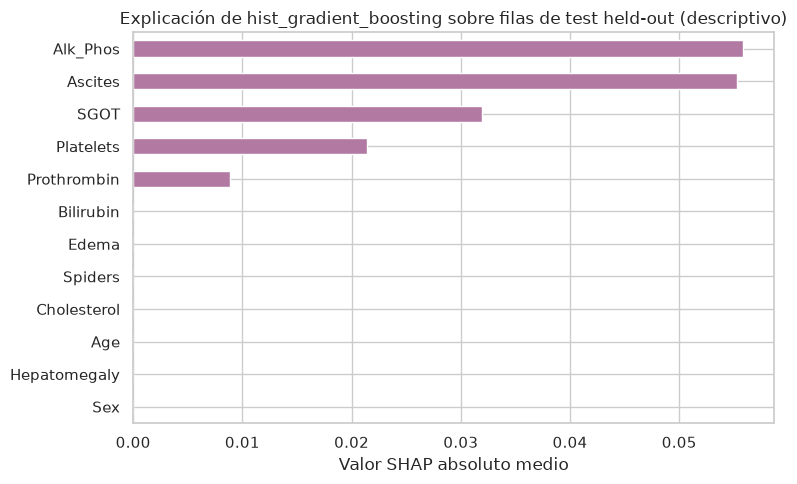

In [22]:
# Explicación SHAP opcional para el comparador primario; su ausencia se maneja con gracia.
try:
    import shap
    shap_available = True
except ImportError as exc:
    shap_available = False
    print("SHAP no disponible; continuando sin explicaciones:", type(exc).__name__)

if shap_available:
    try:
        primary_fitted = final_models[PRIMARY_MODEL].estimator_  # TunedThresholdClassifierCV envuelve el Pipeline ajustado
        preprocess_step = primary_fitted.named_steps["preprocess"]
        estimator_step = primary_fitted.named_steps["model"]
        train_cast = preprocess_step.transform(X_train)
        test_cast = preprocess_step.transform(X_test)

        def encode_for_shap(frame):
            encoded = frame.copy()
            for column in encoded.select_dtypes("category").columns:
                codes = encoded[column].cat.codes.astype(float)
                codes[encoded[column].isna()] = np.nan
                encoded[column] = codes
            return encoded.astype(float)

        background = encode_for_shap(train_cast.sample(min(100, len(train_cast)), random_state=RANDOM_STATE))
        explainer = shap.TreeExplainer(estimator_step, data=background, feature_perturbation="interventional")
        values = explainer(encode_for_shap(test_cast), check_additivity=False)
        mean_abs = pd.Series(np.abs(values.values).mean(axis=0), index=test_cast.columns).sort_values(ascending=False).head(12)
        print(f"Top features SHAP de valor absoluto medio para {PRIMARY_MODEL}:")
        print(mean_abs)
        mean_abs.sort_values().plot.barh(figsize=(8, 5), color="#b279a2")
        plt.title(f"Explicación de {PRIMARY_MODEL} sobre filas de test held-out (descriptivo)")
        plt.xlabel("Valor SHAP absoluto medio")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("SHAP no pudo explicar este pipeline; continuando:", type(exc).__name__, str(exc)[:200])
else:
    print("Instalar shap por separado para explicaciones opcionales; los resultados principales de arriba están completos sin él.")


`hist_gradient_boosting` no expone ni `coef_` ni un único `feature_importances_` como sí lo
hacen `logistic`/`random_forest`, así que su explicación viene del `TreeExplainer` de SHAP sobre
el encoding nativo categórico/consciente de faltantes del pipeline ajustado;
`check_additivity=False` evita un falso positivo de punto flotante conocido en la verificación
de aditividad de SHAP para árboles con gradient boosting, no un bug de este análisis.

Los valores SHAP describen el comportamiento de este modelo ajustado sobre esta cohorte, no
un efecto causal ni el riesgo verdadero de un paciente individual; una feature que puntúa alto
puede reflejar el patrón de cohorte/ausencia estructural documentado arriba tanto como biología.

SHAP se trata como un diagnóstico y generador de hipótesis: cualquier feature con ranking
alto se verifica cruzadamente contra el hallazgo de cohorte antes de sacar conclusiones
clínicas, y esta sección se mantiene opcional (se degrada con gracia si `shap` no está
instalado) así el resto de la notebook nunca queda bloqueado por ella.


## Por qué el pipeline está construido así

Dos propiedades de este dataset hacen riesgoso el manejo ordinario de train/test, y las decisiones de diseño de arriba existen por eso.

La primera es la fuga de datos a través del preprocesamiento. Cualquier imputador o escalador fit sobre el dataset completo, filas de entrenamiento y test juntas, aprende relaciones estadísticas (medias, cuantiles, encodings) que incluyen información de las mismas filas sobre las que después será evaluado. Un valor de laboratorio faltante imputado por un modelo que ya vio los valores reales de otros pacientes de "test", o un escalador ajustado sobre estadísticas del set de test, ambos filtran información del set de test de vuelta a las features con las que el modelo entrena, inflando el desempeño aparente de una manera que no se reproducirá en pacientes genuinamente nuevos. Cada transformador en esta notebook se ajusta exactamente una vez, dentro de `Pipeline.fit(X_train, ...)`, y los datos de test solo pasan alguna vez por `.transform`.

La segunda es la ausencia estructural de datos discutida en la sección de cohorte de arriba: aproximadamente un cuarto del estudio clínico de esta cohorte falta no al azar sino según el brazo de ensayo en el que estuvo el paciente. Imputar ese bloque con un único modelo global, o descartar por completo el patrón de ausencia, descarta información sobre la pertenencia a la cohorte que resulta valer la pena conservar. Por eso `trial_cohort` es un predictor declarado y por eso `hist_gradient_boosting` trata "¿se midió esto?" como una señal en lugar de un defecto a rellenar.

Una tercera elección que vale la pena señalar: reportar las métricas de un único split train/test como el resultado subestima cuánto puede moverse la estimación de una cohorte pequeña, de 412 filas, con el resampleo. La validación cruzada anidada repetida y la corrección de optimismo bootstrap (sección de Validación de arriba) ponen límites honestos y defendibles sobre ese número en su lugar. Las decisiones de preprocesamiento en sí mismas (log1p en laboratorios sesgados, indicadores de faltante eliminados, `Edema` ordinal, árboles de capacidad restringida, tuning de hiperparámetros genuinamente anidado) elevaron el AUROC honesto de CV anidada del modelo logístico sin tocar una sola fila de datos. La mayor parte de la brecha entre "se ve bien en un split" y "realmente reproducible" resultó ser preprocesamiento y especificación del modelo, no los datos en sí.

Nada de esto cambia la conclusión científica subyacente: el estadio de PBC a partir de estos laboratorios y datos demográficos basales es un problema de predicción genuinamente difícil en esta cohorte, y ningún modelo aquí se acerca a discriminación de grado clínico.



## Conclusiones y limitaciones

Bajo validación cruzada anidada repetida, los tres modelos (`logistic`, `random_forest`, `hist_gradient_boosting`) caen aproximadamente en el rango de AUROC 0.65-0.71 para Estadio 3-4 vs Estadio 1-2, con intervalos de confianza superpuestos: ningún modelo es confiablemente mejor que los otros en esta cohorte. El modelo `logistic` regularizado queda ligeramente por detrás de los comparadores basados en árboles bajo CV anidada (0.690 vs. 0.700-0.704) pero muestra la brecha aparente-vs-corregida más pequeña de los tres, evidencia de que sobreajusta menos el fold de entrenamiento. Las estimaciones corregidas por optimismo bootstrap son más altas para los modelos basados en árboles; eso se reporta como una segunda estimación, menos conservadora, no como desempate (ver la sección de Validación sobre por qué los dos métodos difieren).

El análisis de curva de decisión muestra que el modelo primario supera a ambas estrategias ingenuas ("marcar a todos", "no marcar a nadie") solo en un sub-rango de umbrales de riesgo clínicamente plausibles, así que su utilidad depende del umbral, no es incondicional. El tamaño de muestra es una restricción real aquí: 412 filas etiquetadas no alcanzan los criterios de tamaño de muestra mínimo de Riley et al. (2020) para este número de predictores y la prevalencia del outcome de esta cohorte, y el EPV está bien por debajo de la regla convencional de >=10. Ese déficit se refleja directamente en la estabilidad de predicción: las predicciones de reajustes bootstrap para pacientes individuales pueden diferir sustancialmente de las predicciones del modelo original para ese mismo paciente, un modo de falla distinto de una discriminación promedio pobre.

La calibración es imperfecta, y eso se revela en lugar de esconderse. Las pendientes de calibración crudas en el split held-out son 1.56 (`logistic`), 1.76 (`random_forest`), 1.40 (`hist_gradient_boosting`), todas por encima del ideal de 1.0, lo que significa que las probabilidades predichas son demasiado conservadoras (no lo bastante extremas) para este fold de test. En el pipeline más pesado de `03_model_development.ipynb`, intentar la recalibración post-hoc `sigmoid` (`CalibratedClassifierCV`) empeoró la pendiente de cada modelo, no la mejoró (p. ej. `logistic` 1.56 -> 2.53), muy probablemente porque el set de calibración (n=83) es demasiado pequeño para que la recalibración sigmoid estime de forma confiable. Ese resultado negativo se reporta tal cual: a este tamaño de muestra, las probabilidades de esta cohorte deberían leerse como útiles direccionalmente para ordenar riesgo, no como porcentajes literales.

El score de riesgo Mayo PBC de cinco variables, de décadas de antigüedad (Dickson et al. 1989), derivado sobre esta misma cohorte para predecir supervivencia en lugar de estadio, se reporta junto a los modelos de esta notebook como una verificación de sentido, no como una validación externa. Sobre XGBoost: tres miembros de la misma familia de ensamble de árboles ya quedan por debajo de la logística regularizada bajo CV anidada, y el bajo EPV de esta cohorte (van der Ploeg, Austin & Steyerberg 2014; Christodoulou et al. 2019) hace que una cuarta variante de boosting sea una fuente de mejora poco probable, así que no se agregó.

Esta es una única cohorte histórica (1974-1984) de Mayo Clinic con dos subgrupos clínicamente distintos (ensayo aleatorizado vs. registro no aleatorizado) y sin validación externa ni temporal. Los hallazgos no deberían asumirse generalizables a otras poblaciones, épocas, o protocolos diagnósticos. Este es un artefacto de portfolio/investigación, no una herramienta diagnóstica: no reemplaza la biopsia hepática ni la evaluación clínica y no debe informar decisiones de tratamiento.

El análisis más completo vive en `notebooks/01_eda.ipynb`, `02_modeling.ipynb`, y `03_model_development.ipynb`, la versión de producción respaldada por `src/` de este repositorio del mismo pipeline, que corre un presupuesto de CV anidada más pesado (5x5 vs. el 5x3 de esta notebook), hiperparámetros tuneados con Optuna dentro de cada fold externo, explicaciones SHAP, y un comparador `lightgbm`. Ver `README.md` para el layout completo del proyecto.